In [ ]:
import sys
sys.path.insert(0, '../src')

import priceModels as pm
import amOptPricer_corrected as aop

import numpy as np
import matplotlib.pyplot as plt

## Improved Stein-Stein (LLH) model of the price dynamics

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dB_t\\
    dB_t &= B_t dW_t,\,B_0=1\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated brownian motions, $W_t$ independent brownian motion
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters

**Note on Implementation:** The characteristic function coefficients are computed via the ODE system in Eq. (4) of the Lin-Lin-He paper. The implementation correctly handles the τ term in the dD equation: $\partial D/\partial\tau = (u_j i\phi - \frac{1}{2}\phi^2)\tau + \ldots$, where τ is the integration variable. This makes the ODE system non-autonomous (time-dependent), which is properly accounted for in the RK4 integration.

#### 1. Simulate Price Paths

We illustrate how to simulate price paths from the LLH model using Algorithm 2.5 detailed in the report. The values of the model parameters have been selected from the Lin-Lin-He paper, Table 2. Ten thousand paths have been sampled over a 1 year horizon with 252 trading days.

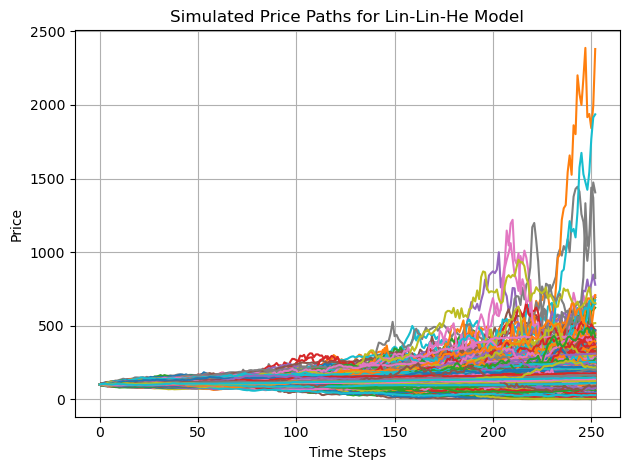

In [2]:
#r=0.3943,  kappa=4.9394, nu=0.3943, sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, rho=0.1691 from the Lin-Lin-He paper Table 2
model_llh = pm.ImprovedSteinStein(
        r=0.3943, rho=0.1691, kappa=4.9394, nu=0.3943,
        sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=123
    )

# Simulate 10,000 paths for 1 year horizon (T=1.0) with 252 trading days
res_llh = model_llh.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths= 10000)

# Plot the simulated price paths
pm.plot(res_llh['S'].T, title="Simulated Price Paths for Lin-Lin-He Model")

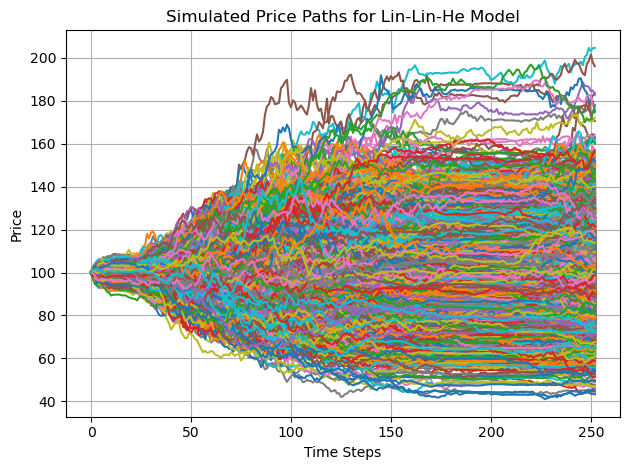

In [ ]:
# #r=0.01,  kappa=5, nu=0.2, sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, rho=-0.2, from the Lin-Lin-He paper Table 1
# model_llh = pm.ImprovedSteinStein(
#         r=0.01, rho=-0.2, kappa=5, nu=0.2,
#         sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, seed=123
#     )

# # Simulate 10,000 paths for 1 year horizon (T=1.0) with 252 trading days
# res_llh = model_llh.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=10000)

# # Plot the simulated price paths
# pm.plot(res_llh['S'].T, title="Simulated Price Paths for Lin-Lin-He Model")

In [3]:
def llh_european_prices(model, S0=100.0, K=90.0, tau=1.0, 
                        n_steps_mc=256, n_paths=1_000_000,
                        phi_max=200.0, n_phi=1023, n_steps_ode=252):
    """
    Compute the prices of European call and put using the LLH formula and MC simulations.
    
    The LLH analytical formula uses the characteristic function approach with ODE 
    coefficients computed via RK4 integration. The implementation correctly accounts 
    for the τ term in equation (4) of the Lin-Lin-He paper, treating it as a 
    non-autonomous ODE system.
    
    Parameters:
      model       : ImprovedSteinStein model instance
      S0          : initial spot price
      K           : strike price
      tau         : time to maturity
      n_steps_mc  : number of MC time discretization steps
      n_paths     : number of MC paths
      phi_max     : maximum φ value for integration
      n_phi       : number of φ nodes for trapezoid quadrature
      n_steps_ode : number of RK4 steps for ODE integration
    """
    
    # Simulate paths for MC pricing
    res = model.simulate_prices(S0=S0, T=tau, n_steps_mc=n_steps_mc, n_paths=n_paths)
    
    # European call price using LLH analytical formula
    price_call = model.price_call_llh(S=S0, K=K, tau=tau, 
                                      vol=model.sigma0, theta=model.theta0,
                                      phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode).item()
    
    # European put price using LLH analytical formula
    price_put = model.price_put_llh(S=S0, K=K, tau=tau, 
                                     vol=model.sigma0, theta=model.theta0,
                                     phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode).item()
    
    # Monte Carlo pricing using the simulated paths
    res_mc = aop.price_call_mc(res['S'], K=K, T=tau, r=model.r)
    price_put_mc = res_mc.get('price') - S0 + K * np.exp(-model.r * tau)

    return {"European call LLH price": price_call,
            "European call MC price": res_mc.get('price'),
            "MC 95% CI": res_mc.get('ci_95'),
            "European put LLH price": price_put,
            "European put MC price": price_put_mc}

In [5]:
S = [90.0, 95.0, 100.0, 105.0, 110.0]
K = [0.9*s for s in S]
n_paths = 1_000_000
tau = 0.083
n_steps_mc = 22  # MC discretization steps
n_steps_ode = 100  # ODE integration steps
phi_max = 300.0
n_phi = 3000 # integration nodes

prices_llh = {}
prices_mc = {}
for k, s in zip(K, S):
    res = llh_european_prices(model_llh, S0=s, K=k, tau=tau, 
                             n_steps_mc=n_steps_mc, n_paths=n_paths,
                             phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)
    prices_llh[s] = res["European call LLH price"]
    prices_mc[s] = res["European call MC price"]

In [6]:
prices_llh

{90.0: 11.712637627822417,
 95.0: 12.363339718257023,
 100.0: 13.014041808691601,
 105.0: 13.664743899126137,
 110.0: 14.315445989560757}

In [7]:
prices_mc

{90.0: 12.141220645182075,
 95.0: 12.815732903247754,
 100.0: 13.490245161313418,
 105.0: 14.16475741937909,
 110.0: 14.839269677444758}

In [8]:
bias = {s: np.round((prices_mc[s] - prices_llh[s])/prices_mc[s]*100,2) for s in S}
bias

{90.0: 3.53, 95.0: 3.53, 100.0: 3.53, 105.0: 3.53, 110.0: 3.53}

Next:
- Identify whether the source of systematic bias is the in the simulation of the paths or volatility (used the alternative formulas that i derived)
    - The bias sustains within 3% for both Simpson's quadrature and the trapezoid rule for 1 month maturity
    - The bias reduces considerably (sustains at 14%) when using the trapezoid rule for 1 year maturity
    - Following the stoch cal derivation, revise the computation of the characterisitcs f_j. f_j depend on v_t and theta_t, this impacts the Rasmussen CV! NEED I SIMULATE VOLATILTIY PATHS ALONG WITH PRICE PATHS FOR THE PRICING OF PATH DEPENDENT OPTIONS.  
- Code the heuristic of the american price once the european price is known




- Check the stiffness of the ODE system
- Refactor with the computation of the integral using the trapezoidal method as suggested in the Lin-Lin-He paper
- Fix things for 1 month maturity and time the computations for MC and LLH approaches